Loading images...


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:14<00:00,  1.82s/it]


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 12544)             0         
                                                                 
 dense (Dense)               (None, 128)               1

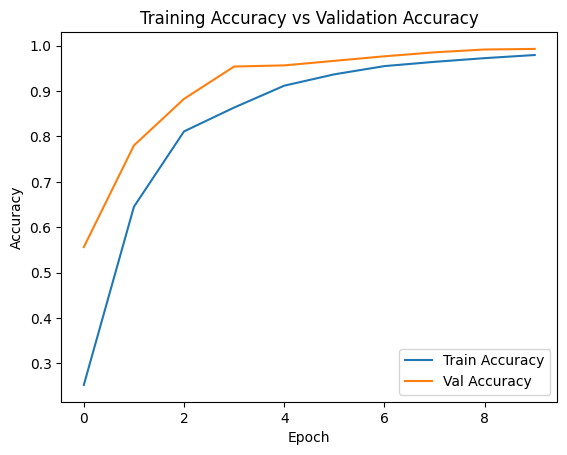

In [1]:
!pip install matplotlib
!pip install scikit-learn
!pip install tqdm

# Step 1: Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tqdm import tqdm  # for progress bar

# Step 2: Set Dataset Path
train_dir = r"D:\Hand gesture dataset\asl_alphabet_train\asl_subset"

# Step 3: Parameters
IMG_SIZE = 64  # Resize all images to 64x64
EPOCHS = 10    # You can increase later
BATCH_SIZE = 64

# Step 4: Load & Preprocess Data
data = []
labels = []

print("Loading images...")
for label in tqdm(os.listdir(train_dir)):
    if label.startswith('.'):  # skip hidden/system files
        continue
    label_path = os.path.join(train_dir, label)
    for img_file in os.listdir(label_path)[:500]:  # load first 500 images per class to save RAM
        try:
            img_path = os.path.join(label_path, img_file)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img)
            labels.append(label)
        except Exception as e:
            pass  # skip corrupted images

# Step 5: Convert to NumPy Arrays
data = np.array(data) / 255.0  # Normalize
labels = np.array(labels)

# Step 6: Encode Labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)

# Step 7: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Step 8: Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(lb.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Step 9: Train the Model
history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_test, y_test))

# Step 10: Save the Model
model.save("asl_hand_gesture_model.h5")
print("✅ Model trained and saved as 'asl_hand_gesture_model.h5'")

# Optional: Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy vs Validation Accuracy')
plt.show()


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelBinarizer
import os

# Load trained model
model = load_model("asl_hand_gesture_model.h5")

# Recreate label binarizer from training
gesture_labels = sorted(os.listdir(r"D:\Hand gesture dataset\asl_alphabet_train\asl_subset"))  # same folder used during training
lb = LabelBinarizer()
lb.fit(gesture_labels)

# Webcam config
img_size = 64
cap = cv2.VideoCapture(0)

print("Press 'q' to quit.")
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Define ROI (Region of Interest) for hand (can adjust these values)
    x1, y1, x2, y2 = 100, 100, 300, 300
    roi = frame[y1:y2, x1:x2]

    # Preprocess ROI
    roi_resized = cv2.resize(roi, (img_size, img_size))
    roi_normalized = roi_resized / 255.0
    roi_expanded = np.expand_dims(roi_normalized, axis=0)

    # Predict
    predictions = model.predict(roi_expanded)
    predicted_class = lb.inverse_transform(predictions)[0]
    confidence = np.max(predictions)

    # Display prediction
    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(frame, f'{predicted_class} ({confidence*100:.2f}%)', (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    cv2.imshow("Hand Gesture Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
q
cap.release()
cv2.destroyAllWindows()
